# MSCS 634 – Lab Assignment 1
**Name:** [Your Name]  
**Course Title:** MSCS 634 – Advanced Data Science  
**Lab Title:** Data Visualization, Preprocessing, and Statistical Analysis  
**Dataset:** Titanic Passenger Dataset

---
## Step 1: Data Collection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid')

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# Load dataset
df = pd.read_csv('titanic.csv')

print(f'Dataset shape: {df.shape}')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')

Dataset shape: (891, 12)
Rows: 891, Columns: 12


In [3]:
# Display first five rows (Screenshot Required)
print('=== First 5 Rows of Dataset ===')
df.head()

=== First 5 Rows of Dataset ===


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


---
## Step 2: Data Visualization

### 2.1 Scatter Plot – Age vs. Fare

C:\Users\pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\matplotlib\colors.py:2243: UserWarning: Warning: converting a masked element to nan.
  dtype = np.min_scalar_type(value)
C:\Users\pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\matplotlib\colors.py:2250: UserWarning: Warning: converting a masked element to nan.
  data = np.asarray(value)
C:\Users\pc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\matplotlib\ticker.py:563: UserWarning: Warning: converting a masked element to nan.
  else fmt % arg)
C:\Users\pc\AppData\Local\Temp\ipykernel_35592\1926602189.py:7: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  legend = ax.legend(

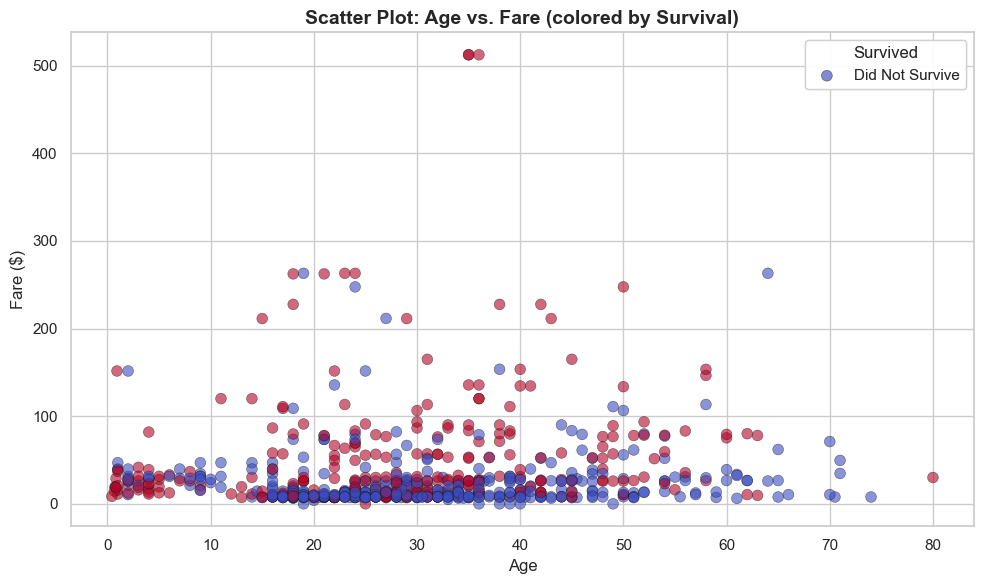

Insight: Passengers who paid higher fares (first class) tend to cluster at higher ages and show a higher survival rate (blue dots). Low-fare passengers are concentrated at lower ages and are predominantly non-survivors (red dots).


In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    df['Age'], df['Fare'],
    c=df['Survived'], cmap='coolwarm',
    alpha=0.6, edgecolors='k', linewidths=0.4, s=60
)
legend = ax.legend(*scatter.legend_elements(), title='Survived', labels=['Did Not Survive', 'Survived'])
ax.add_artist(legend)
ax.set_title('Scatter Plot: Age vs. Fare (colored by Survival)', fontsize=14, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Fare ($)')
plt.tight_layout()
plt.savefig('viz_scatter_age_fare.png', dpi=150)
plt.show()
print('Insight: Passengers who paid higher fares (first class) tend to cluster at higher ages and show a higher survival rate (blue dots). Low-fare passengers are concentrated at lower ages and are predominantly non-survivors (red dots).')

### 2.2 Bar Chart – Survival Count by Passenger Class

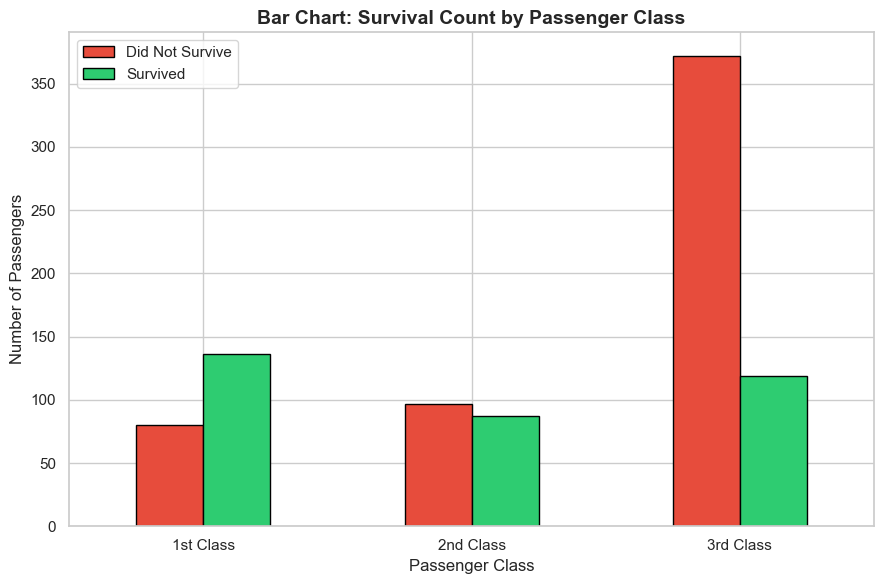

Insight: First-class passengers had the highest survival rate relative to their class size, while third-class passengers experienced the most deaths — reflecting the well-documented socioeconomic disparity in survival outcomes.


In [5]:
survival_by_class = df.groupby(['Pclass', 'Survived']).size().unstack(fill_value=0)
survival_by_class.columns = ['Did Not Survive', 'Survived']
survival_by_class.index = ['1st Class', '2nd Class', '3rd Class']

ax = survival_by_class.plot(kind='bar', color=['#e74c3c', '#2ecc71'], edgecolor='black', figsize=(9, 6))
ax.set_title('Bar Chart: Survival Count by Passenger Class', fontsize=14, fontweight='bold')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Number of Passengers')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend()
plt.tight_layout()
plt.savefig('viz_bar_survival_class.png', dpi=150)
plt.show()
print('Insight: First-class passengers had the highest survival rate relative to their class size, while third-class passengers experienced the most deaths — reflecting the well-documented socioeconomic disparity in survival outcomes.')

### 2.3 Histogram – Age Distribution

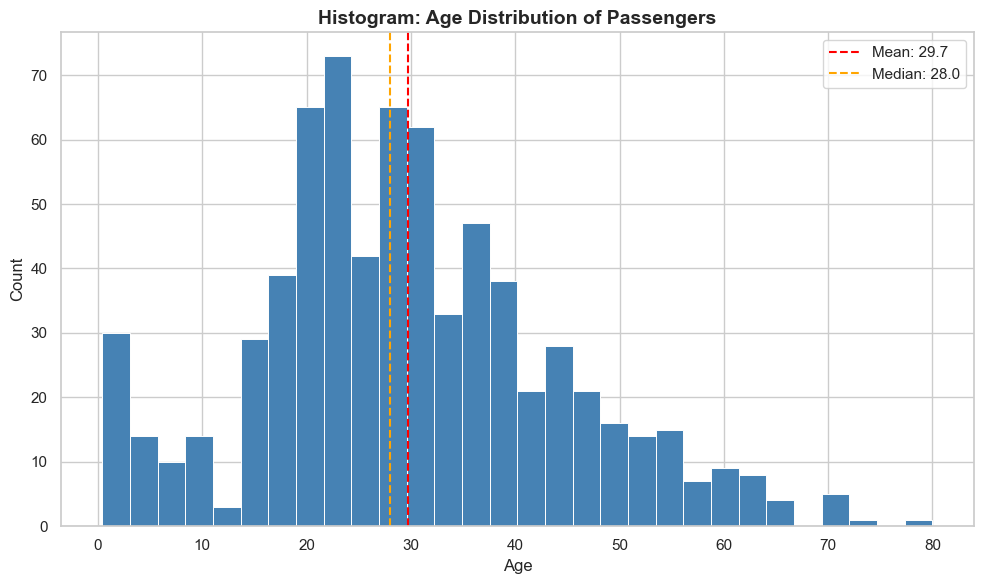

Insight: The age distribution is right-skewed with most passengers between 20–40 years old. The mean (29.7) is slightly higher than the median (28.0), confirming mild positive skew. A small but notable spike exists in the 0–5 range (children onboard).


In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df['Age'].dropna(), bins=30, color='steelblue', edgecolor='white', linewidth=0.7)
ax.axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=1.5, label=f"Mean: {df['Age'].mean():.1f}")
ax.axvline(df['Age'].median(), color='orange', linestyle='--', linewidth=1.5, label=f"Median: {df['Age'].median():.1f}")
ax.set_title('Histogram: Age Distribution of Passengers', fontsize=14, fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('viz_hist_age.png', dpi=150)
plt.show()
print('Insight: The age distribution is right-skewed with most passengers between 20–40 years old. The mean (29.7) is slightly higher than the median (28.0), confirming mild positive skew. A small but notable spike exists in the 0–5 range (children onboard).')

### 2.4 Box Plot – Fare by Passenger Class

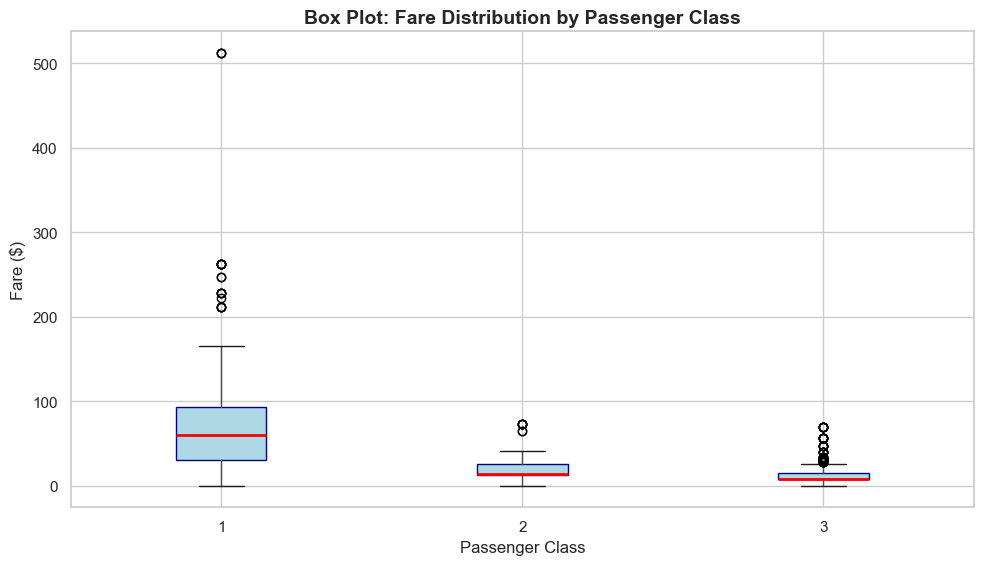

Insight: First-class fares show a much wider spread and numerous extreme outliers, indicating premium pricing variability. Second and third class fares are tightly clustered at lower values, with third class being the most compact.


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
df.boxplot(column='Fare', by='Pclass', ax=ax, patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='navy'),
           medianprops=dict(color='red', linewidth=2))
ax.set_title('Box Plot: Fare Distribution by Passenger Class', fontsize=14, fontweight='bold')
plt.suptitle('')
ax.set_xlabel('Passenger Class')
ax.set_ylabel('Fare ($)')
plt.tight_layout()
plt.savefig('viz_box_fare_class.png', dpi=150)
plt.show()
print('Insight: First-class fares show a much wider spread and numerous extreme outliers, indicating premium pricing variability. Second and third class fares are tightly clustered at lower values, with third class being the most compact.')

### 2.5 Pie Chart – Gender Distribution

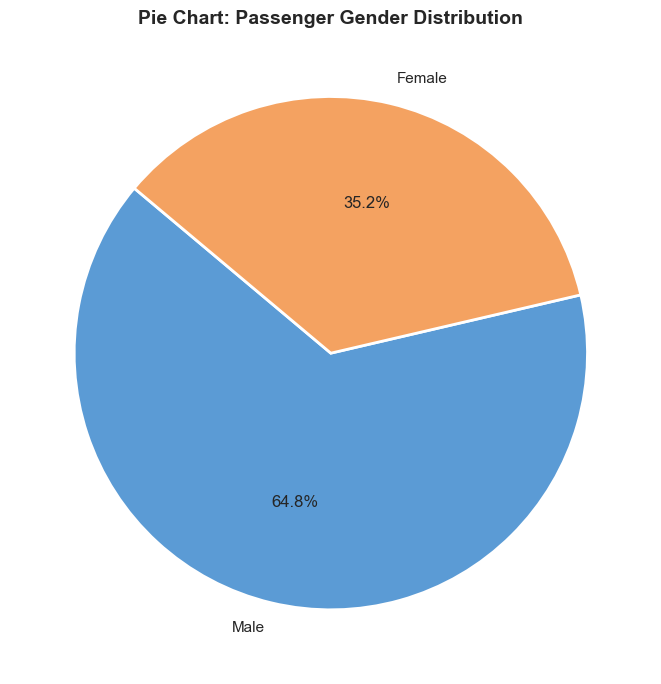

Insight: About 64.8% of passengers were male and 35.2% were female. Despite males being the majority, females had a significantly higher survival rate due to the "women and children first" evacuation policy.


In [8]:
sex_counts = df['Sex'].value_counts()
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(sex_counts, labels=['Male', 'Female'], autopct='%1.1f%%',
       colors=['#5b9bd5', '#f4a261'], startangle=140,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Pie Chart: Passenger Gender Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_pie_gender.png', dpi=150)
plt.show()
print('Insight: About 64.8% of passengers were male and 35.2% were female. Despite males being the majority, females had a significantly higher survival rate due to the "women and children first" evacuation policy.')

### 2.6 Line Plot – Cumulative Survivors by Passenger ID

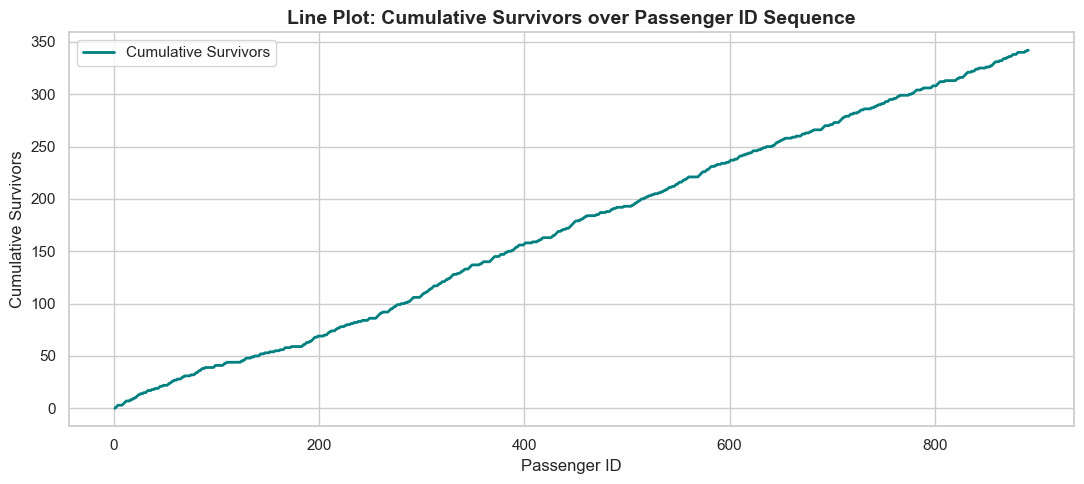

Insight: The cumulative survivor count grows roughly linearly, indicating survivors are distributed throughout the manifest rather than clustered. The final count shows approximately 342 survivors out of 891 passengers (~38.4% survival rate).


In [9]:
df_sorted = df.sort_values('PassengerId').reset_index(drop=True)
df_sorted['CumulativeSurvived'] = df_sorted['Survived'].cumsum()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df_sorted['PassengerId'], df_sorted['CumulativeSurvived'],
        color='teal', linewidth=2, label='Cumulative Survivors')
ax.set_title('Line Plot: Cumulative Survivors over Passenger ID Sequence', fontsize=14, fontweight='bold')
ax.set_xlabel('Passenger ID')
ax.set_ylabel('Cumulative Survivors')
ax.legend()
plt.tight_layout()
plt.savefig('viz_line_cumulative_survivors.png', dpi=150)
plt.show()
print('Insight: The cumulative survivor count grows roughly linearly, indicating survivors are distributed throughout the manifest rather than clustered. The final count shows approximately 342 survivors out of 891 passengers (~38.4% survival rate).')

---
## Step 3: Data Preprocessing

### 3.1 Handling Missing Values

In [10]:
# Dataset BEFORE handling missing values (Screenshot Required)
print('=== Missing Values BEFORE Preprocessing ===')
missing_before = df.isnull().sum()
missing_pct_before = (df.isnull().sum() / len(df) * 100).round(2)
missing_report = pd.DataFrame({'Missing Count': missing_before, 'Missing %': missing_pct_before})
print(missing_report[missing_report['Missing Count'] > 0])
print(f'\nDataset shape before: {df.shape}')

=== Missing Values BEFORE Preprocessing ===
          Missing Count  Missing %
Age                 177      19.87
Cabin               687      77.10
Embarked              2       0.22

Dataset shape before: (891, 12)


In [11]:
# Apply missing value handling
df_clean = df.copy()

# Age: fill with median (robust to outliers)
age_median = df_clean['Age'].median()
df_clean['Age'] = df_clean['Age'].fillna(age_median)
print(f'Age: filled {df["Age"].isnull().sum()} missing values with median ({age_median})')

# Embarked: fill with mode (most common port)
embarked_mode = df_clean['Embarked'].mode()[0]
df_clean['Embarked'] = df_clean['Embarked'].fillna(embarked_mode)
print(f'Embarked: filled {df["Embarked"].isnull().sum()} missing values with mode ("{embarked_mode}")')

# Cabin: drop column (>77% missing — not imputable)
df_clean.drop(columns=['Cabin'], inplace=True)
print(f'Cabin: dropped column (too many missing values)')

Age: filled 177 missing values with median (28.0)
Embarked: filled 2 missing values with mode ("S")
Cabin: dropped column (too many missing values)


In [12]:
# Dataset AFTER handling missing values (Screenshot Required)
print('=== Missing Values AFTER Preprocessing ===')
missing_after = df_clean.isnull().sum()
print(missing_after)
print(f'\nDataset shape after: {df_clean.shape}')

=== Missing Values AFTER Preprocessing ===
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Dataset shape after: (891, 11)


### 3.2 Outlier Detection and Removal (IQR Method)

In [13]:
# IQR calculation for 'Fare' (Screenshot Required)
Q1 = df_clean['Fare'].quantile(0.25)
Q3 = df_clean['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print('=== IQR Outlier Detection: Fare ===')
print(f'Q1 (25th percentile) : {Q1:.2f}')
print(f'Q3 (75th percentile) : {Q3:.2f}')
print(f'IQR                  : {IQR:.2f}')
print(f'Lower Bound          : {lower_bound:.2f}')
print(f'Upper Bound          : {upper_bound:.2f}')

outliers_fare = df_clean[(df_clean['Fare'] < lower_bound) | (df_clean['Fare'] > upper_bound)]
print(f'\nOutliers identified  : {len(outliers_fare)}')
print(outliers_fare[['PassengerId', 'Pclass', 'Fare']].head(10))

=== IQR Outlier Detection: Fare ===
Q1 (25th percentile) : 7.91
Q3 (75th percentile) : 31.00
IQR                  : 23.09
Lower Bound          : -26.72
Upper Bound          : 65.63

Outliers identified  : 116
     PassengerId  Pclass      Fare
1              2       1   71.2833
27            28       1  263.0000
31            32       1  146.5208
34            35       1   82.1708
52            53       1   76.7292
61            62       1   80.0000
62            63       1   83.4750
72            73       2   73.5000
88            89       1  263.0000
102          103       1   77.2875


In [14]:
# Remove outliers and display shape before/after (Screenshot Required)
print(f'Shape BEFORE outlier removal: {df_clean.shape}')
df_no_outliers = df_clean[(df_clean['Fare'] >= lower_bound) & (df_clean['Fare'] <= upper_bound)].copy()
print(f'Shape AFTER  outlier removal: {df_no_outliers.shape}')
print(f'Rows removed: {len(df_clean) - len(df_no_outliers)}')

Shape BEFORE outlier removal: (891, 11)
Shape AFTER  outlier removal: (775, 11)
Rows removed: 116


### 3.3 Data Reduction

In [15]:
# Dataset BEFORE data reduction (Screenshot Required)
print('=== Dataset BEFORE Data Reduction ===')
print(f'Shape: {df_clean.shape}')
print(f'Columns: {list(df_clean.columns)}')
df_clean.head(3)

=== Dataset BEFORE Data Reduction ===
Shape: (891, 11)
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S


In [16]:
# 1. Dimension elimination: drop less analytical columns
df_reduced = df_clean.drop(columns=['PassengerId', 'Name', 'Ticket'])
print('Dropped columns: PassengerId, Name, Ticket (identifiers, not predictive)')

# 2. Row sampling: take 70% sample
df_sampled = df_reduced.sample(frac=0.70, random_state=42).reset_index(drop=True)

# Dataset AFTER data reduction (Screenshot Required)
print('\n=== Dataset AFTER Data Reduction ===')
print(f'Shape: {df_sampled.shape}')
print(f'Columns: {list(df_sampled.columns)}')
df_sampled.head(5)

Dropped columns: PassengerId, Name, Ticket (identifiers, not predictive)

=== Dataset AFTER Data Reduction ===
Shape: (624, 8)
Columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,3,male,28.0,1,1,15.2458,C
1,0,2,male,31.0,0,0,10.5000,S
2,0,3,male,20.0,0,0,7.9250,S
3,1,2,female,6.0,0,1,33.0000,S
4,1,3,female,14.0,1,0,11.2417,C


### 3.4 Data Scaling and Discretization

In [17]:
# Dataset BEFORE scaling (Screenshot Required)
print('=== Age and Fare Stats BEFORE Scaling ===')
print(df_sampled[['Age', 'Fare']].describe().round(2))

=== Age and Fare Stats BEFORE Scaling ===
          Age    Fare
count  624.00  624.00
mean    29.24   31.85
std     13.15   49.42
min      0.75    0.00
25%     22.00    7.92
50%     28.00   14.50
75%     35.00   30.18
max     80.00  512.33


In [18]:
df_scaled = df_sampled.copy()

# Min-Max Scaling for Fare
fare_min, fare_max = df_scaled['Fare'].min(), df_scaled['Fare'].max()
df_scaled['Fare_MinMax'] = (df_scaled['Fare'] - fare_min) / (fare_max - fare_min)

# Z-score Standardization for Age
df_scaled['Age_Zscore'] = (df_scaled['Age'] - df_scaled['Age'].mean()) / df_scaled['Age'].std()

# Discretize Age into meaningful bins
age_bins = [0, 12, 18, 35, 60, 100]
age_labels = ['Child', 'Teen', 'Young Adult', 'Middle-Aged', 'Senior']
df_scaled['Age_Group'] = pd.cut(df_scaled['Age'], bins=age_bins, labels=age_labels, right=True)

# Dataset AFTER scaling (Screenshot Required)
print('=== Age and Fare Stats AFTER Scaling ===')
print(df_scaled[['Age', 'Age_Zscore', 'Fare', 'Fare_MinMax', 'Age_Group']].head(8))
print('\nAge_Group distribution:')
print(df_scaled['Age_Group'].value_counts())

=== Age and Fare Stats AFTER Scaling ===
    Age  Age_Zscore     Fare  Fare_MinMax    Age_Group
0  28.0   -0.094318  15.2458     0.029758  Young Adult
1  31.0    0.133874  10.5000     0.020495  Young Adult
2  20.0   -0.702832   7.9250     0.015469  Young Adult
3   6.0   -1.767732  33.0000     0.064412        Child
4  14.0   -1.159218  11.2417     0.021942         Teen
5  26.0   -0.246447  78.8500     0.153905  Young Adult
6  28.0   -0.094318   7.7500     0.015127  Young Adult
7  16.0   -1.007089  18.0000     0.035134         Teen

Age_Group distribution:
Age_Group
Young Adult    374
Middle-Aged    134
Child           52
Teen            48
Senior          16
Name: count, dtype: int64


---
## Step 4: Statistical Analysis

### 4.1 General Overview of Data

In [19]:
# .info() output (Screenshot Required)
print('=== df.info() ===')
df_clean.info()

=== df.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [20]:
# .describe() output (Screenshot Required)
print('=== df.describe() ===')
df_clean.describe().round(2)

=== df.describe() ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,891.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.36,0.52,0.38,32.20
std,257.35,0.49,0.84,13.02,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,22.00,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,35.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


### 4.2 Central Tendency Measures

In [21]:
# Central tendency for numeric columns (Screenshot Required)
numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']

central_tendency = pd.DataFrame({
    'Min':    df_clean[numeric_cols].min(),
    'Max':    df_clean[numeric_cols].max(),
    'Mean':   df_clean[numeric_cols].mean().round(2),
    'Median': df_clean[numeric_cols].median(),
    'Mode':   df_clean[numeric_cols].mode().iloc[0]
})

print('=== Central Tendency Measures ===')
print(central_tendency)

=== Central Tendency Measures ===
        Min       Max   Mean   Median   Mode
Age    0.42   80.0000  29.36  28.0000  28.00
Fare   0.00  512.3292  32.20  14.4542   8.05
SibSp  0.00    8.0000   0.52   0.0000   0.00
Parch  0.00    6.0000   0.38   0.0000   0.00


### 4.3 Dispersion Measures

In [22]:
# Dispersion measures (Screenshot Required)
dispersion = pd.DataFrame({
    'Range':   df_clean[numeric_cols].max() - df_clean[numeric_cols].min(),
    'Q1':      df_clean[numeric_cols].quantile(0.25),
    'Q3':      df_clean[numeric_cols].quantile(0.75),
    'IQR':     df_clean[numeric_cols].quantile(0.75) - df_clean[numeric_cols].quantile(0.25),
    'Variance':df_clean[numeric_cols].var().round(2),
    'Std Dev': df_clean[numeric_cols].std().round(2)
})

print('=== Dispersion Measures ===')
print(dispersion)

=== Dispersion Measures ===
          Range       Q1    Q3      IQR  Variance  Std Dev
Age     79.5800  22.0000  35.0  13.0000    169.51    13.02
Fare   512.3292   7.9104  31.0  23.0896   2469.44    49.69
SibSp    8.0000   0.0000   1.0   1.0000      1.22     1.10
Parch    6.0000   0.0000   0.0   0.0000      0.65     0.81


### 4.4 Correlation Analysis

In [23]:
# Correlation matrix (Screenshot Required)
corr_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr_matrix = df_clean[corr_cols].corr().round(3)

print('=== Correlation Matrix ===')
print(corr_matrix)

=== Correlation Matrix ===
          Survived  Pclass    Age  SibSp  Parch   Fare
Survived     1.000  -0.338 -0.065 -0.035  0.082  0.257
Pclass      -0.338   1.000 -0.340  0.083  0.018 -0.549
Age         -0.065  -0.340  1.000 -0.233 -0.172  0.097
SibSp       -0.035   0.083 -0.233  1.000  0.415  0.160
Parch        0.082   0.018 -0.172  0.415  1.000  0.216
Fare         0.257  -0.549  0.097  0.160  0.216  1.000


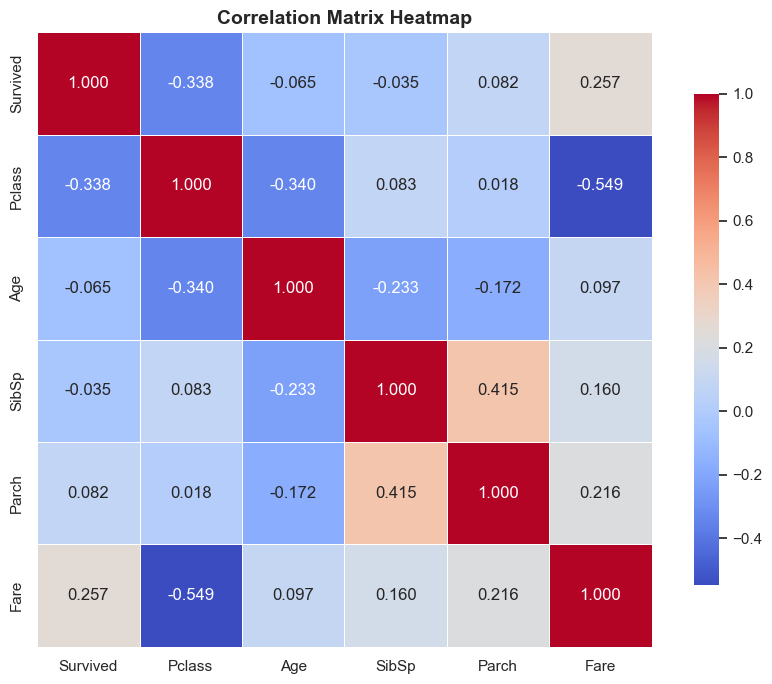

Insight: Pclass has the strongest negative correlation with Survival (-0.34) and Fare (+0.55), confirming that higher-class passengers (lower Pclass number) paid more and survived more. Age shows a weak negative correlation with survival.


In [24]:
# Heatmap of correlation matrix
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_heatmap_correlation.png', dpi=150)
plt.show()
print('Insight: Pclass has the strongest negative correlation with Survival (-0.34) and Fare (+0.55), confirming that higher-class passengers (lower Pclass number) paid more and survived more. Age shows a weak negative correlation with survival.')

---
## Summary of Key Findings

| Topic | Key Insight |
|---|---|
| Survival Rate | ~38.4% of passengers survived |
| Class Disparity | 1st class passengers survived at much higher rates |
| Missing Data | Age (19.9%), Cabin (77.1%) had significant missing values |
| Fare Outliers | 116 fare outliers detected and removed via IQR method |
| Correlation | Pclass strongly (negatively) correlated with Fare and Survival |
| Age Distribution | Most passengers were 20–40 years old (right-skewed) |